# Laboratorio: Aprendizaje Supervisado
## Regresión y Clasificación Binaria con scikit-learn

**Curso:** CC3085 – Inteligencia Artificial  

**Integrantes:**
- Diego Rosales - 23258
- Diego López -


# Parte 1 — Problema de Regresión
**Dataset:** California Housing


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

## 1. Carga y exploración de datos
### Carga del dataset

Las variables independientes (`X`) y la variable objetivo (`y`) se separan explícitamente
siguiendo el enfoque estándar de aprendizaje supervisado. Esto permite entrenar y evaluar
modelos de forma clara, ya que los algoritmos de `scikit-learn` esperan esta estructura
para el proceso de ajuste y predicción.

El DataFrame combinado se utiliza únicamente con fines de exploración y análisis
descriptivo.

In [103]:
# Cargar el dataset
housing = fetch_california_housing(as_frame=True)

# Variables independientes
X = housing.data
# Variable objetivo
y = housing.target

# Unir todo en un solo DataFrame para facilitar la exploración
df = pd.concat([X, y.rename("MedHouseValue")], axis=1)

# Mostrar las primeras filas
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Estadísticas descriptivas


In [104]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Distribución de la variable objetivo

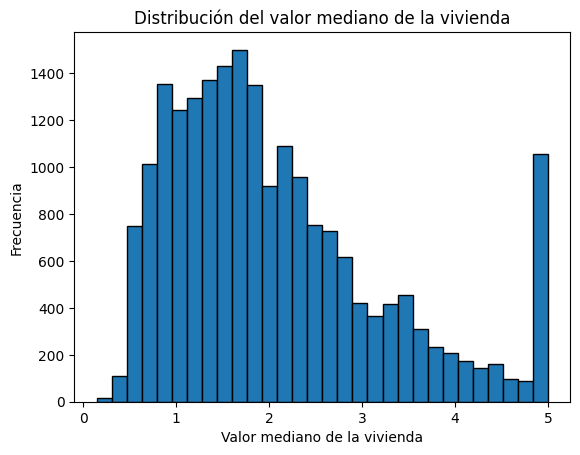

In [105]:
plt.hist(df["MedHouseValue"], bins=30, edgecolor="black")
plt.xlabel("Valor mediano de la vivienda")
plt.ylabel("Frecuencia")
plt.title("Distribución del valor mediano de la vivienda")
plt.show()

## 2. Separación de datos


La función `train_test_split` se utiliza para dividir el conjunto de datos en dos
subconjuntos: uno de entrenamiento y otro de prueba. El conjunto de entrenamiento
se emplea para ajustar los modelos, mientras que el conjunto de prueba se utiliza
para evaluar su desempeño sobre datos que el modelo no ha visto previamente.

Esta separación es fundamental en aprendizaje supervisado, ya que permite estimar
la capacidad de generalización del modelo y detectar posibles problemas de sobreajuste,
es decir, cuando un modelo aprende demasiado bien los datos de entrenamiento pero
tiene un mal desempeño en datos nuevos.

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 16512 muestras
Tamaño del conjunto de prueba: 4128 muestras


Se utiliza un valor de `test_size = 0.2`, lo que corresponde a una división 80% para
entrenamiento y 20% para prueba. Esta proporción es ampliamente utilizada en la
práctica, ya que ofrece un buen balance entre disponer de suficientes datos para que
el modelo aprenda patrones relevantes y contar con un conjunto de prueba lo
suficientemente grande para evaluar su desempeño de manera confiable.

El parámetro `random_state` se fija con el valor 42 para controlar la aleatoriedad
del proceso de partición. El número 42 no tiene un significado estadístico especial,
sino que se utiliza por convención en la comunidad como un valor arbitrario pero
consistente. Fijar este valor garantiza que la división de los datos sea reproducible,
es decir, que al ejecutar el notebook múltiples veces se obtengan exactamente los
mismos subconjuntos de entrenamiento y prueba.

## 3. Entrenamiento inicial de modelos
En esta sección se entrenan distintos modelos de regresión utilizando sus
hiperparámetros por defecto. El objetivo es obtener una primera referencia
del desempeño de cada modelo antes de realizar cualquier proceso de
optimización.


In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Métricas de evaluación

Para evaluar el desempeño de los modelos de regresión se utilizan las
siguientes métricas:

- **MAE (Mean Absolute Error):** mide el error promedio absoluto entre los
  valores reales y las predicciones.
- **RMSE (Root Mean Squared Error):** penaliza más fuertemente los errores
  grandes, ya que eleva las diferencias al cuadrado.
- **R² (Coeficiente de determinación):** indica qué proporción de la variabilidad
  de la variable objetivo es explicada por el modelo.

In [108]:
def evaluar_regresion(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

### Regresión Lineal
Se entrena un modelo de Regresión Lineal como línea base, ya que es un modelo
simple que permite capturar relaciones lineales entre las variables
independientes y la variable objetivo.


In [109]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr, rmse_lr, r2_lr = evaluar_regresion(y_test, y_pred_lr)

mae_lr, rmse_lr, r2_lr

(0.5332001304956557, np.float64(0.7455813830127758), 0.5757877060324514)

### Árbol de Decisión para Regresión
El Árbol de Decisión es un modelo no lineal que divide el espacio de variables
en regiones, permitiendo capturar relaciones más complejas entre las
características.

In [110]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt, rmse_dt, r2_dt = evaluar_regresion(y_test, y_pred_dt)

mae_dt, rmse_dt, r2_dt

(0.45467918846899225, np.float64(0.7037294974840077), 0.622075845135081)

### Random Forest para Regresión
Random Forest es un modelo de conjunto que combina múltiples árboles de
decisión entrenados sobre diferentes subconjuntos de los datos, lo que
permite mejorar la capacidad de generalización y reducir el sobreajuste.

In [111]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf, rmse_rf, r2_rf = evaluar_regresion(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(0.32754256845930246, np.float64(0.5053399773665033), 0.8051230593157366)

### Comparación de resultados iniciales

A continuación, se comparan los resultados obtenidos por cada modelo utilizando
sus hiperparámetros por defecto, evaluados sobre el conjunto de prueba.

In [112]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Árbol de Decisión", "Random Forest"],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf],
    "R2": [r2_lr, r2_dt, r2_rf]
})

resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,0.533200,0.745581,0.575788
1,Árbol de Decisión,0.454679,0.703729,0.622076
2,Random Forest,0.327543,0.505340,0.805123


## 4. Optimización de hiperparámetros
En esta sección se realiza la optimización de hiperparámetros para los modelos
basados en árboles, con el objetivo de mejorar su desempeño y reducir el riesgo
de sobreajuste observado en el entrenamiento inicial.
\

### Elección del método de búsqueda

Para el Árbol de Decisión se utiliza `GridSearchCV`, ya que el número de
hiperparámetros relevantes es reducido y permite evaluar exhaustivamente
todas las combinaciones posibles.

Para Random Forest se emplea `RandomizedSearchCV`, dado que el espacio de
búsqueda es considerablemente mayor. Este enfoque permite explorar de manera
eficiente distintas combinaciones de hiperparámetros con un menor costo
computacional.

In [113]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### Optimización del Árbol de Decisión
Se optimizan hiperparámetros que controlan la complejidad del árbol, tales como
la profundidad máxima y el tamaño mínimo de las hojas, los cuales influyen
directamente en el sobreajuste y la capacidad de generalización del modelo.


In [114]:
param_grid_dt = {
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

In [115]:
dt_gs = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

dt_gs.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [116]:
dt_gs.best_params_


{'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}

In [117]:
best_dt = dt_gs.best_estimator_

y_pred_dt_opt = best_dt.predict(X_test)
mae_dt_opt, rmse_dt_opt, r2_dt_opt = evaluar_regresion(y_test, y_pred_dt_opt)

mae_dt_opt, rmse_dt_opt, r2_dt_opt


(0.4041270341593175, np.float64(0.59777745113437), 0.7273081251592183)

### Optimización de Random Forest
En el caso de Random Forest se optimizan hiperparámetros relacionados con la
cantidad de árboles y la complejidad de cada uno, así como el número de
variables consideradas en cada división.


In [118]:
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}


In [119]:
rf_rs = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42
)

rf_rs.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

In [120]:
rf_rs.best_params_


{'n_estimators': 200,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 30}

In [121]:
best_rf = rf_rs.best_estimator_

y_pred_rf_opt = best_rf.predict(X_test)
mae_rf_opt, rmse_rf_opt, r2_rf_opt = evaluar_regresion(y_test, y_pred_rf_opt)

mae_rf_opt, rmse_rf_opt, r2_rf_opt

(0.3211024427740011, np.float64(0.4920872119028723), 0.81521049676918)

### Esquema de validación cruzada

Se utiliza validación cruzada con `cv = 5`, lo que implica que el conjunto de
entrenamiento se divide en cinco particiones. Cada modelo se entrena y evalúa
cinco veces, utilizando una partición distinta como validación en cada
iteración. Este esquema permite obtener una estimación más robusta del
desempeño del modelo y reduce la dependencia de una única partición de los
datos.


## 5. Evaluación del rendimiento
En esta sección se evalúa y compara el desempeño de los modelos de regresión
entrenados, utilizando métricas adecuadas para este tipo de problema. El
análisis se realiza sobre el conjunto de prueba, con el fin de medir la
capacidad de generalización de cada modelo.

In [122]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Árbol de Decisión (Optimizado)",
        "Random Forest (Optimizado)"
    ],
    "MAE": [
        mae_lr,
        mae_dt_opt,
        mae_rf_opt
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt_opt,
        rmse_rf_opt
    ],
    "R2": [
        r2_lr,
        r2_dt_opt,
        r2_rf_opt
    ]
})

comparacion


,Modelo,MAE,RMSE,R2
0,Regresión Lineal,0.533200,0.745581,0.575788
1,Árbol de Decisión (Optimizado),0.404127,0.597777,0.727308
2,Random Forest (Optimizado),0.321102,0.492087,0.815210


### Comparación del desempeño de los modelos

A partir de las métricas obtenidas, se observa que los modelos basados en
árboles presentan un mejor desempeño que la regresión lineal, lo cual indica
que existen relaciones no lineales entre las variables independientes y la
variable objetivo.

El modelo de Random Forest optimizado muestra el mejor desempeño general,
obteniendo los valores más bajos de MAE y RMSE, así como el mayor coeficiente
R². Esto sugiere una mejor capacidad de generalización en comparación con los
otros modelos evaluados.
